# Real-Data LightGBM Models

This notebook runs the direct per-step LightGBM experiment on meter `MT_252` from the UCI electricity load data. The chronological test split stays untouched until final selection and scoring.

The main comparison is the full-trajectory MAE for 1-hour and 24-hour horizons. The notebook also exports per-step errors, gain importance, and SHAP summaries for model interpretation.

SHAP and gain are read as associations with the fitted model, not causal effects.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from tqdm import TqdmWarning
warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)
import shap

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.baselines import naive_forecast, seasonal_naive_forecast, select_ridge_alpha
from src.config import RAW_DATA_DIR, RAW_DATA_FILENAME, FIGURES_DIR, TABLES_DIR
from src.data_loader import load_electricity_load_data
from src.evaluate import evaluate_multistep, per_step_metrics
from src.features import build_baseline_features
from src.forecasting import make_multistep_targets, split_supervised_by_time
from src.ml_models import aggregate_gain_importance, select_lightgbm_candidate

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)


## Load Data

The raw UCI file is loaded from `data/raw/LD2011_2014.txt`. Only meter `MT_252` is used for this experiment.

In [2]:
raw_path = RAW_DATA_DIR / RAW_DATA_FILENAME
if not raw_path.exists():
    raise FileNotFoundError(f"Dataset not found: {raw_path}")
raw_df = load_electricity_load_data(raw_path)
series = raw_df["MT_252"].rename("load")
features = build_baseline_features(series)
print(f"Series rows: {len(series):,}; feature rows: {len(features):,}")


Series rows: 140,256; feature rows: 139,584


## Fit Direct LightGBM Models

For each horizon, targets are built from future steps, aligned on the feature index, and split chronologically. The validation fold selects the LightGBM candidate; the test fold is scored once after selection.

The trajectory metric table reports the complete multi-step MAE plus endpoint MAE. Per-step errors are kept for the lead-time plot, and the feature-importance table aggregates gain across all fitted step-specific models.

In [3]:
HORIZONS = {"1h": 4, "24h": 96}
metric_rows = []
step_frames = []
search_frames = []
importance_frames = []
artifacts = {}

for horizon_label, horizon in HORIZONS.items():
    targets = make_multistep_targets(series, horizon).dropna()
    common_index = features.index.intersection(targets.index)
    X = features.loc[common_index]
    y = targets.loc[common_index]
    splits = split_supervised_by_time(X, y, series.index, horizon)
    X_train, y_train = splits["train"]
    X_val, y_val = splits["validation"]
    X_test, y_test = splits["test"]

    ridge_model, _ = select_ridge_alpha(X_train, y_train, X_val, y_val)
    lgbm_model, search = select_lightgbm_candidate(
        X_train, y_train, X_val, y_val, parallel_jobs=-1
    )
    search.insert(0, "horizon", horizon_label)
    search_frames.append(search)

    predictions = {
        "Naive": naive_forecast(X_test["current_load"], horizon),
        "Seasonal Naive": seasonal_naive_forecast(series, X_test.index, horizon),
        "Ridge": ridge_model.predict(X_test),
        "LightGBM": lgbm_model.predict(X_test),
    }
    horizon_metrics = {}
    for model_name, prediction in predictions.items():
        metrics = evaluate_multistep(y_test, prediction)
        horizon_metrics[model_name] = metrics
        metric_rows.append(
            {
                "horizon": horizon_label,
                "horizon_steps": horizon,
                "model": model_name,
                **metrics,
            }
        )
        by_step = per_step_metrics(y_test, prediction)
        by_step.insert(0, "model", model_name)
        by_step.insert(0, "horizon", horizon_label)
        step_frames.append(by_step)

    importance = aggregate_gain_importance(lgbm_model)
    importance.insert(0, "horizon", horizon_label)
    importance_frames.append(importance)
    artifacts[horizon_label] = {
        "X_test": X_test,
        "y_test": y_test,
        "predictions": predictions,
        "lgbm_model": lgbm_model,
    }

metrics_df = pd.DataFrame(metric_rows)
for horizon_label in HORIZONS:
    mask = metrics_df["horizon"].eq(horizon_label)
    seasonal_mae = metrics_df.loc[
        mask & metrics_df["model"].eq("Seasonal Naive"), "MAE"
    ].item()
    lgbm_mask = mask & metrics_df["model"].eq("LightGBM")
    metrics_df.loc[lgbm_mask, "improvement_vs_seasonal_pct"] = (
        (seasonal_mae - metrics_df.loc[lgbm_mask, "MAE"]) / seasonal_mae * 100.0
    )

step_metrics_df = pd.concat(step_frames, ignore_index=True)
search_df = pd.concat(search_frames, ignore_index=True)
importance_df = pd.concat(importance_frames, ignore_index=True)
metrics_df.to_csv(TABLES_DIR / "ml_model_metrics.csv", index=False)
step_metrics_df.to_csv(TABLES_DIR / "ml_metrics_by_step.csv", index=False)
search_df.to_csv(TABLES_DIR / "lgbm_parameter_search.csv", index=False)
importance_df.to_csv(TABLES_DIR / "lgbm_feature_importance.csv", index=False)
metrics_df


,horizon,horizon_steps,model,MAE,RMSE,MAPE,Endpoint_MAE,improvement_vs_seasonal_pct
0,1h,4,Naive,16.970033,27.091910,10.377395,21.557127,NaN
1,1h,4,Seasonal Naive,15.395150,24.912657,9.443368,15.394528,NaN
2,1h,4,Ridge,16.241292,22.759766,10.033431,20.180177,NaN
3,1h,4,LightGBM,12.691339,18.213296,8.867489,13.460911,17.562746
4,24h,96,Naive,75.092625,96.866962,44.866767,15.417331,NaN
5,24h,96,Seasonal Naive,15.326554,24.723413,9.399252,15.417331,NaN
6,24h,96,Ridge,24.380781,31.952616,14.574504,14.383238,NaN
7,24h,96,LightGBM,18.091800,26.737783,12.256312,14.650247,-18.042192


## Forecast Examples

Each panel uses the same test-origin position inside its horizon so the short and long trajectory comparisons stay aligned.

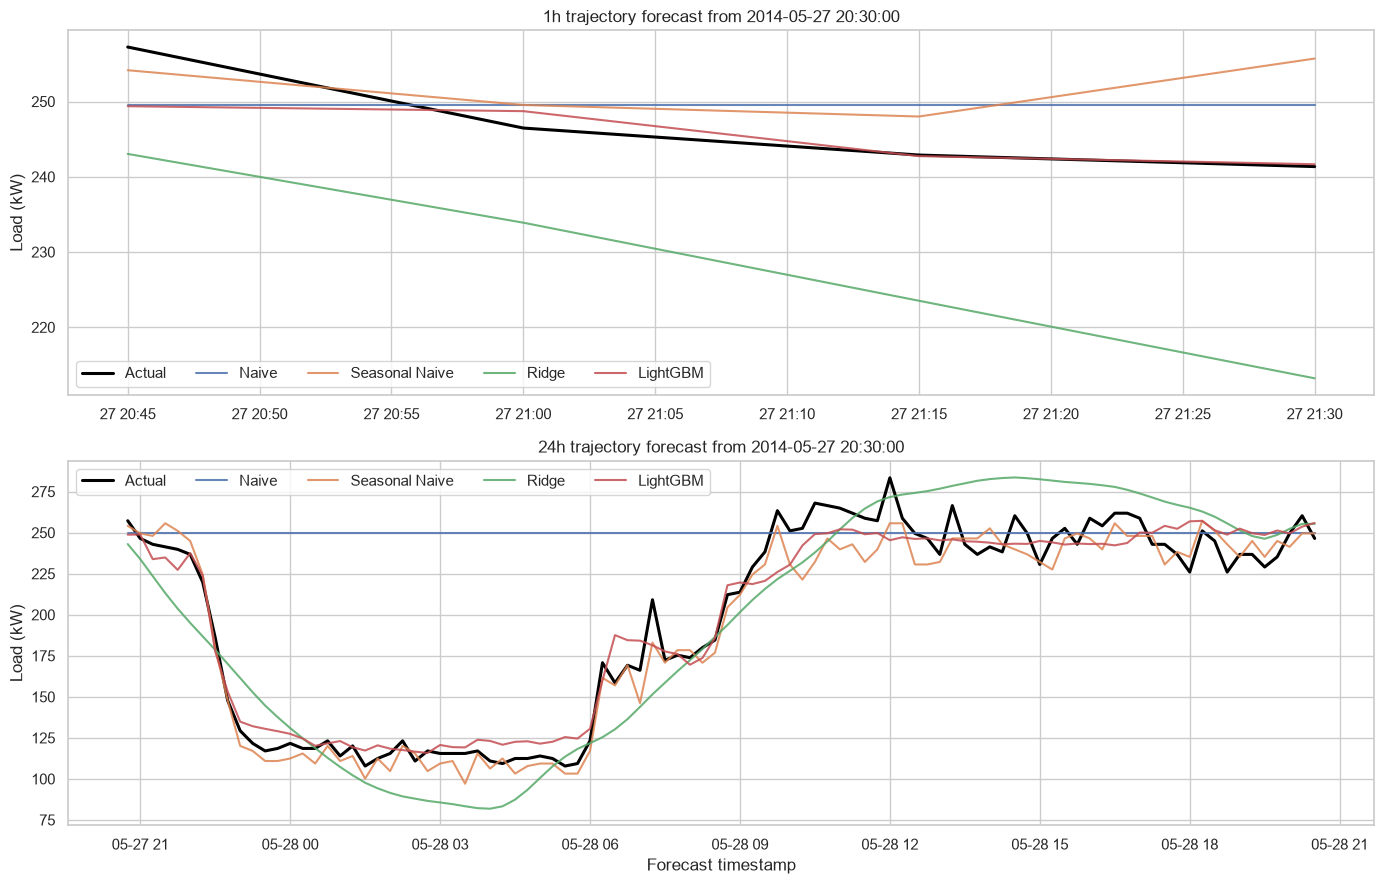

In [4]:
COLORS = {
    "Actual": "black",
    "Naive": "#4C72B0",
    "Seasonal Naive": "#DD8452",
    "Ridge": "#55A868",
    "LightGBM": "#C44E52",
}
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, (horizon_label, horizon) in zip(axes, HORIZONS.items()):
    artifact = artifacts[horizon_label]
    position = min(96, len(artifact["y_test"]) - 1)
    origin = artifact["y_test"].index[position]
    future_index = pd.date_range(
        origin + pd.Timedelta(minutes=15), periods=horizon, freq="15min"
    )
    ax.plot(
        future_index,
        artifact["y_test"].iloc[position],
        color=COLORS["Actual"],
        linewidth=2.2,
        label="Actual",
    )
    for model_name, prediction in artifact["predictions"].items():
        ax.plot(
            future_index,
            prediction[position],
            color=COLORS[model_name],
            alpha=0.85,
            label=model_name,
        )
    ax.set_title(f"{horizon_label} trajectory forecast from {origin}")
    ax.set_ylabel("Load (kW)")
    ax.legend(ncol=5)
axes[-1].set_xlabel("Forecast timestamp")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lgbm_forecast_examples.png", dpi=160)
plt.show()


## Lead-Time Error

Per-step MAE shows how error changes as the forecast lead grows.

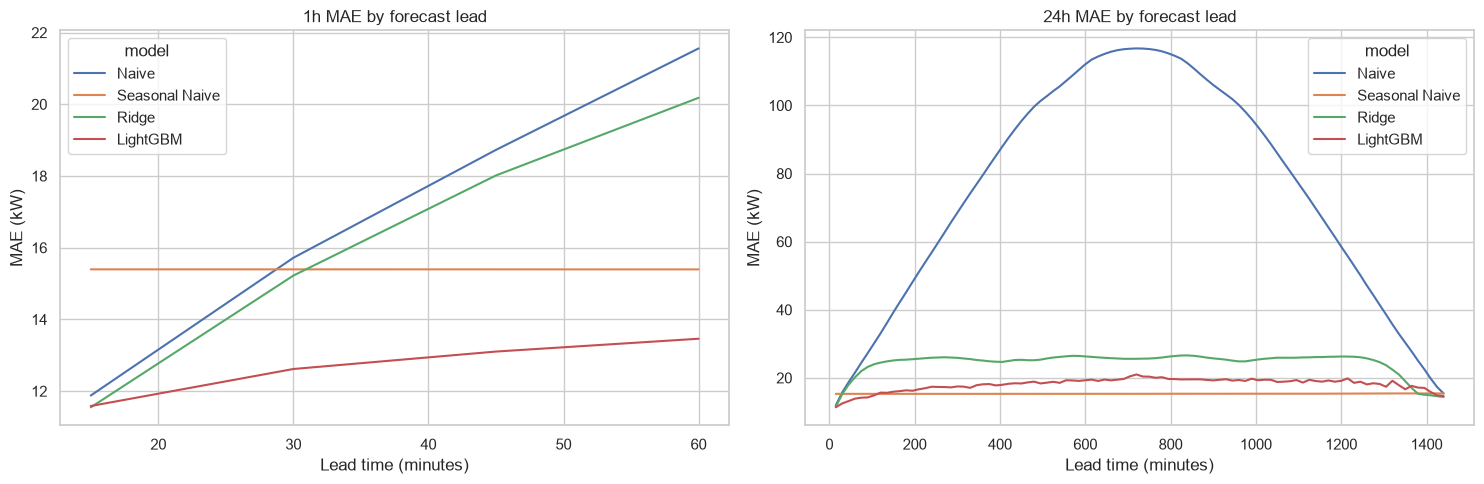

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, horizon_label in zip(axes, HORIZONS):
    subset = step_metrics_df[step_metrics_df["horizon"].eq(horizon_label)]
    sns.lineplot(
        data=subset,
        x="lead_minutes",
        y="MAE",
        hue="model",
        palette=COLORS,
        ax=ax,
    )
    ax.set_title(f"{horizon_label} MAE by forecast lead")
    ax.set_xlabel("Lead time (minutes)")
    ax.set_ylabel("MAE (kW)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lgbm_mae_by_step.png", dpi=160)
plt.show()


## Results

The tables are written to `reports/tables/` and the figures to `reports/figures/`.

In [6]:
display(metrics_df.sort_values(["horizon_steps", "MAE"]))
display(search_df)


,horizon,horizon_steps,model,MAE,RMSE,MAPE,Endpoint_MAE,improvement_vs_seasonal_pct
3,1h,4,LightGBM,12.691339,18.213296,8.867489,13.460911,17.562746
1,1h,4,Seasonal Naive,15.395150,24.912657,9.443368,15.394528,NaN
2,1h,4,Ridge,16.241292,22.759766,10.033431,20.180177,NaN
0,1h,4,Naive,16.970033,27.091910,10.377395,21.557127,NaN
5,24h,96,Seasonal Naive,15.326554,24.723413,9.399252,15.417331,NaN
7,24h,96,LightGBM,18.091800,26.737783,12.256312,14.650247,-18.042192
6,24h,96,Ridge,24.380781,31.952616,14.574504,14.383238,NaN
4,24h,96,Naive,75.092625,96.866962,44.866767,15.417331,NaN


,horizon,candidate,num_leaves,learning_rate,n_estimators,min_child_samples,reg_lambda,validation_MAE,selected
0,1h,small,15,0.05,300,40,1.0,11.005781,False
1,1h,medium,31,0.05,400,20,0.1,10.982308,True
2,1h,large,63,0.03,500,20,0.1,11.013353,False
3,24h,small,15,0.05,300,40,1.0,13.779314,True
4,24h,medium,31,0.05,400,20,0.1,13.875818,False
5,24h,large,63,0.03,500,20,0.1,14.006557,False


## Gain Importance

Gain and SHAP show fitted-model associations, not causal effects.

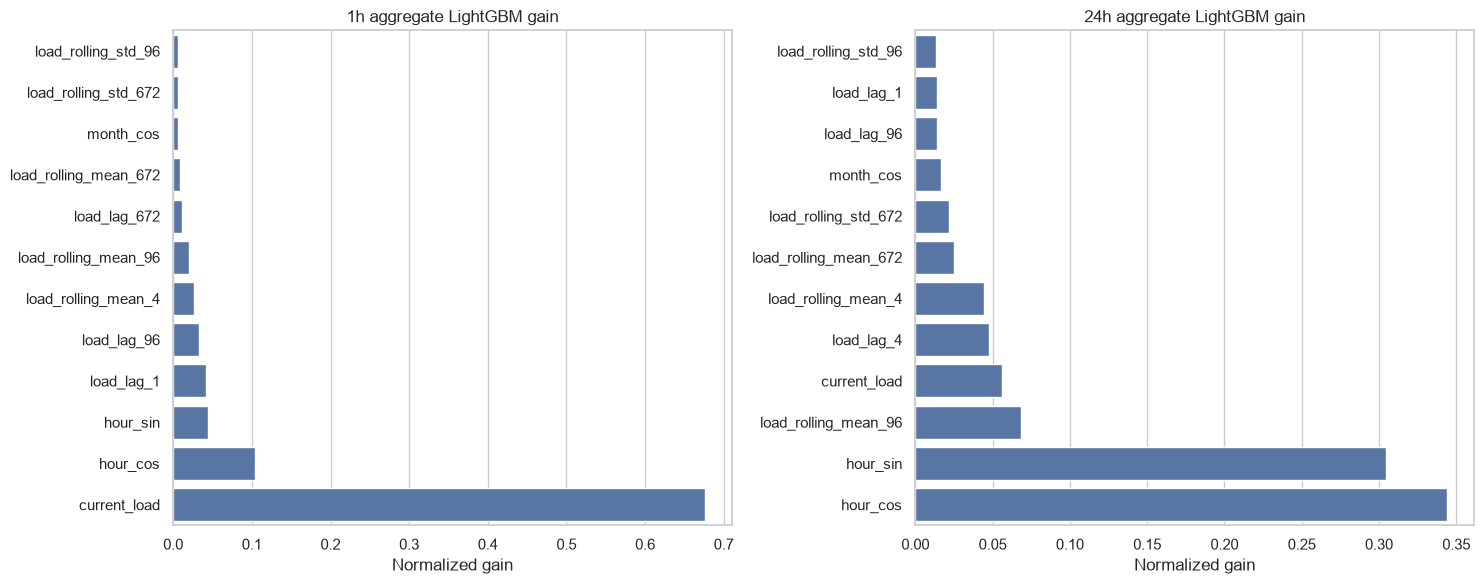

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, horizon_label in zip(axes, HORIZONS):
    top = (
        importance_df[importance_df["horizon"].eq(horizon_label)]
        .nsmallest(12, "rank")
        .sort_values("normalized_gain")
    )
    sns.barplot(data=top, x="normalized_gain", y="feature", ax=ax, color="#4C72B0")
    ax.set_title(f"{horizon_label} aggregate LightGBM gain")
    ax.set_xlabel("Normalized gain")
    ax.set_ylabel("")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lgbm_feature_importance.png", dpi=160)
plt.show()


## SHAP Summary

The SHAP view uses a bounded 500-row test sample per horizon and exactly six step-specific estimators. A small compatibility guard keeps regression outputs and panel binding stable across the installed SHAP/matplotlib versions.

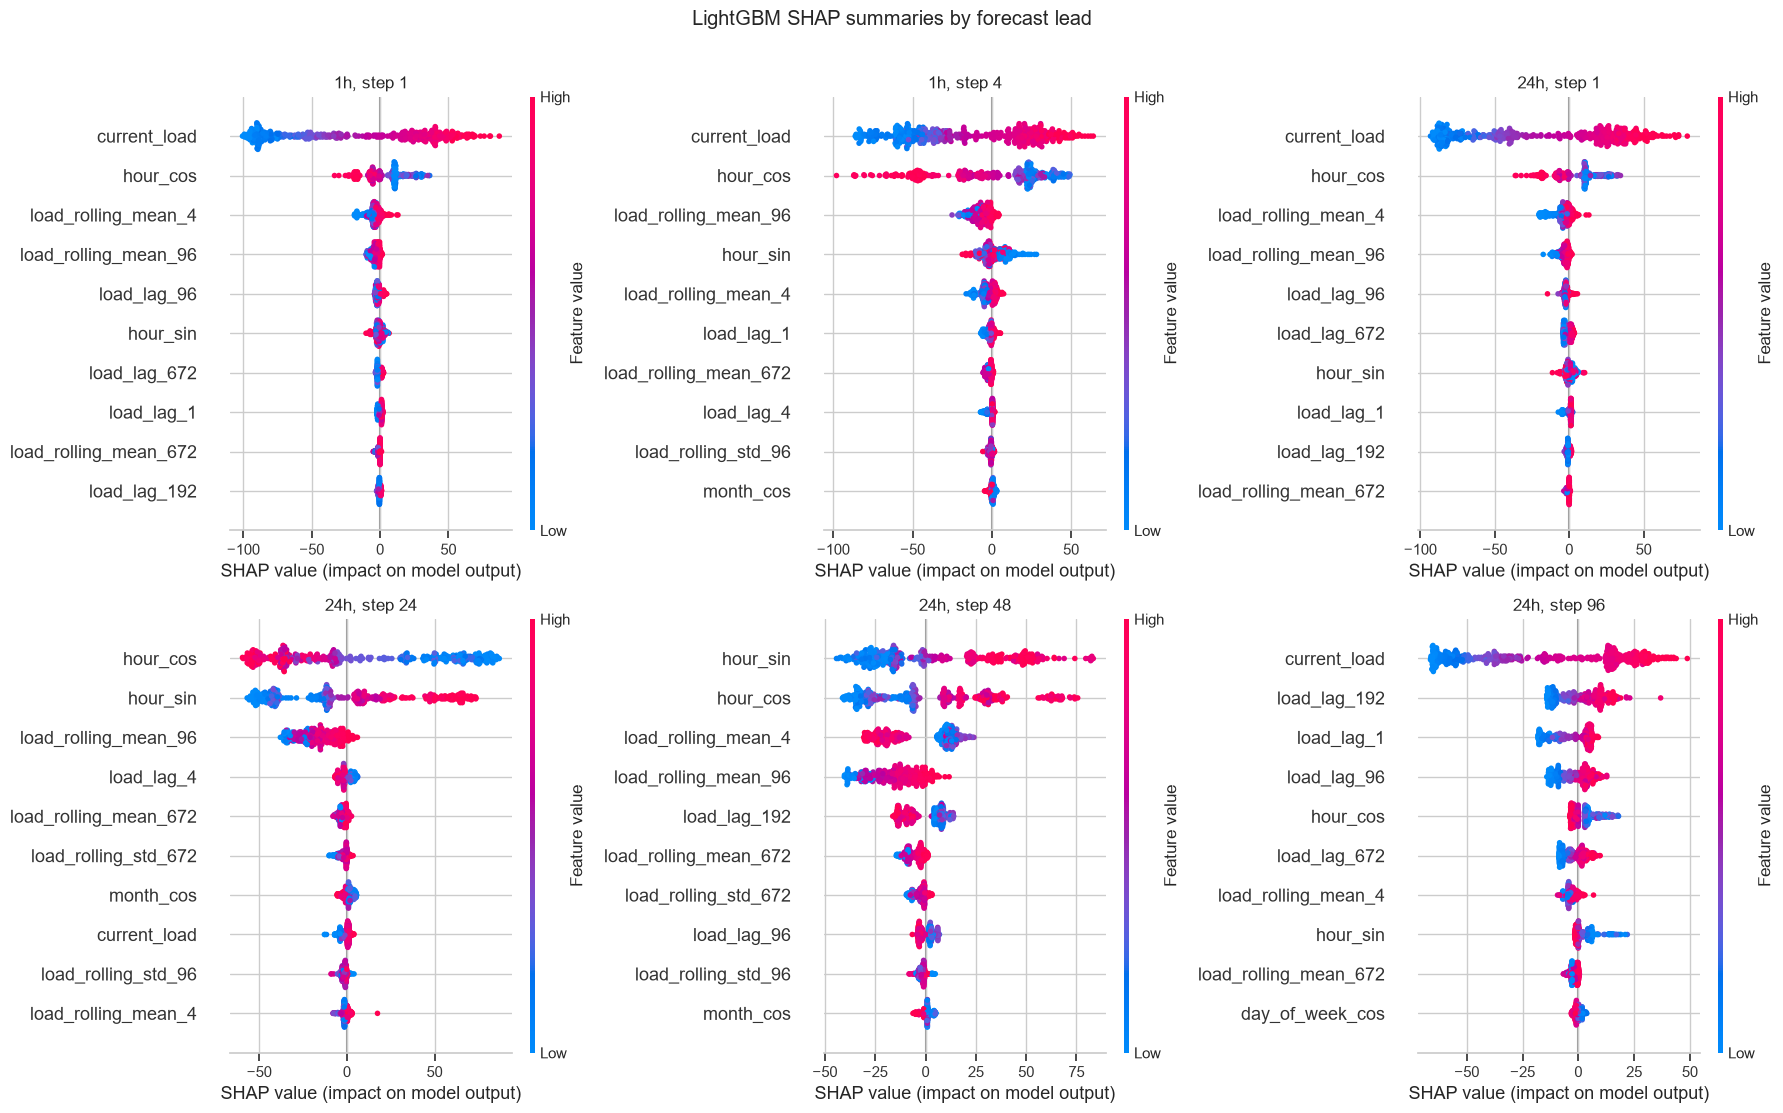

In [8]:
SHAP_STEPS = {"1h": [1, 4], "24h": [1, 24, 48, 96]}
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
flat_axes = axes.ravel()
panel = 0
for horizon_label, steps in SHAP_STEPS.items():
    artifact = artifacts[horizon_label]
    X_sample = artifact["X_test"].sample(
        n=min(500, len(artifact["X_test"])), random_state=42
    )
    for step in steps:
        model = artifact["lgbm_model"].models[step - 1]
        explainer = shap.TreeExplainer(model.booster_)
        shap_values = explainer.shap_values(X_sample)
        if isinstance(shap_values, (list, tuple)):
            shap_values = shap_values[0]
        plt.sca(flat_axes[panel])
        shap.summary_plot(
            shap_values,
            X_sample,
            max_display=10,
            show=False,
            plot_size=None,
        )
        flat_axes[panel].set_title(f"{horizon_label}, step {step}")
        panel += 1
fig.suptitle("LightGBM SHAP summaries by forecast lead", y=1.01)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "lgbm_shap_summary.png", dpi=160, bbox_inches="tight")
plt.show()
